In [53]:
from pathlib import Path
from typing import Any
import numpy as np
from scipy import io
from io import StringIO
import pandas as pd
import h5py
import matplotlib.pyplot as plt
import seaborn as sns


In [39]:
sns.set_theme()

In [24]:
data_dir = Path('/home/inbarm/ProjectAquarium/docs/wave-spectrum/RaDyO_archive')
data_file = data_dir / 'RaDyO_saturation_spectra.mat'
mat_files = sorted(data_dir.rglob('*.mat'))

In [65]:
table1_laxague2018 = pd.read_csv(StringIO("""\
run,  U10,   u_star, wind_dir, Tp,    Hs,   kpHs_2, Cp,    Cp_u_star, swell_dominated, outlier, case_study
1,    5.10,  0.189,  256.4,    4.32,  0.68, 0.073,  6.74,   35.67,    False,           False,   False
2,    6.19,  0.189,  262.4,    4.07,  0.71, 0.086,  6.35,   33.61,    False,           False,   False
3,    5.62,  0.196,  274.7,    4.08,  0.66, 0.081,  6.36,   32.44,    False,           False,   False
4,    7.55,  0.268,  271.1,    3.90,  0.71, 0.094,  6.08,   22.71,    False,           False,   False
5,    5.26,  0.199,  247.5,    3.35,  0.55, 0.099,  5.22,   26.15,    False,           False,   False
6,    5.71,  0.198,  280.4,    3.26,  0.54, 0.104,  5.09,   25.69,    False,           False,   False
7,    5.44,  0.235,  275.1,    3.14,  0.54, 0.109,  4.90,   20.87,    False,           False,   False
8,    6.34,  0.205,  255.4,    2.67,  0.52, 0.148,  4.17,   20.31,    False,           False,   False
9,    9.29,  0.388,  253.6,    3.51,  0.95, 0.155,  5.47,   14.11,    False,           False,   True
10,   7.16,  0.288,  259.9,    4.57,  1.01, 0.098,  7.12,   24.74,    False,           False,   False
11,   4.96,  0.118,  268.6,    5.38,  0.65, 0.045,  8.40,   71.51,    False,           False,   False
12,   5.45,  0.213,  266.3,    5.62,  1.28, 0.082,  8.77,   41.14,    False,           True,    False
13,   1.98,  0.043,  267.8,   10.95,  0.85, 0.014, 17.08,  398.61,    True,            False,   False
14,   1.88,  0.029,  347.5,   10.95,  0.72, 0.012, 17.08,  577.25,    True,            False,   False
15,   1.32,  0.091,  261.3,    9.55,  0.79, 0.017, 14.90,  164.14,    True,            False,   False
16,   1.45,  0.192,  260.2,    8.13,  0.96, 0.029, 12.68,   65.93,    False,           True,    False
"""), skipinitialspace=True)

# table1_laxague2018 = table1_laxague2018.set_index('run')

In [25]:
with h5py.File(data_file, 'r') as f:
    f.visititems(lambda name, obj: print(f'{name}: {type(obj).__name__}, shape={getattr(obj, "shape", "-")}'))    

#refs#: Group, shape=-
#refs#/A: Dataset, shape=(1, 348)
#refs#/B: Dataset, shape=(1, 348)
#refs#/C: Dataset, shape=(1, 348)
#refs#/D: Dataset, shape=(1, 348)
#refs#/E: Dataset, shape=(1, 348)
#refs#/F: Dataset, shape=(1, 348)
#refs#/G: Dataset, shape=(1, 348)
#refs#/a: Dataset, shape=(2,)
#refs#/b: Dataset, shape=(1, 348)
#refs#/c: Dataset, shape=(1, 348)
#refs#/d: Dataset, shape=(1, 348)
#refs#/e: Dataset, shape=(1, 348)
#refs#/f: Dataset, shape=(1, 348)
#refs#/g: Dataset, shape=(1, 348)
#refs#/h: Dataset, shape=(1, 348)
#refs#/i: Dataset, shape=(1, 348)
#refs#/j: Dataset, shape=(1, 348)
#refs#/k: Dataset, shape=(1, 348)
#refs#/l: Dataset, shape=(1, 348)
#refs#/m: Dataset, shape=(1, 348)
#refs#/n: Dataset, shape=(1, 348)
#refs#/o: Dataset, shape=(1, 348)
#refs#/p: Dataset, shape=(1, 348)
#refs#/q: Dataset, shape=(1, 348)
#refs#/r: Dataset, shape=(1, 348)
#refs#/s: Dataset, shape=(1, 348)
#refs#/t: Dataset, shape=(1, 348)
#refs#/u: Dataset, shape=(1, 348)
#refs#/v: Dataset, shape=(1, 

In [93]:
def _h5_to_dict(obj, file):
    if isinstance(obj, h5py.Dataset):
        data = obj[()]
        # dereference object references (MATLAB cell arrays)
        if data.dtype == 'object' or h5py.check_dtype(ref=data.dtype):
            return np.array([[file[ref][()] for ref in row] for row in data], dtype=object)
        return data
    elif isinstance(obj, h5py.Group):
        return {k: _h5_to_dict(obj[k], file) for k in obj.keys() if not k.startswith('#')}
    return obj

def load_mat(path) -> dict[str, Any]:
    try:
        with h5py.File(path, 'r') as f:
            return {key: _h5_to_dict(f[key], f) for key in f.keys() if not key.startswith('#')}
    except OSError:
        data = io.loadmat(path, squeeze_me=True, struct_as_record=False)
        return {key: val for key, val in data.items() if not key.startswith('__')}


In [52]:
data_dir = Path('/home/inbarm/ProjectAquarium/docs/wave-spectrum/RaDyO_archive')
mat_files = sorted(data_dir.rglob('*.mat'))

for fn in mat_files:
    print(fn.name)




RaDyO_saturation_spectra.mat
Rmss.mat
hara_98.mat
hwang_96.mat
jahne_riemer_90.mat
kawai_79.mat
kp_tail_data.mat
laxague_15.mat
model_spectra.mat
probability_density_functions.mat
riegl_wse.mat


In [81]:
content_models = load_mat(data_dir / 'model_spectra.mat')
print(content_models.keys())
print(content_models['yurovskaya13']['B'].shape)

dict_keys(['elfouhaily97', 'hwang11', 'kudryavtsev99', 'yurovskaya13'])
(9, 1, 200, 1)


In [83]:
content_models = load_mat(data_dir / 'Rmss.mat')
print(content_models.keys())
print(content_models['yurovskaya13_obs_ustar'])

dict_keys(['coxmunk_Rmss', 'coxmunk_ustar', 'radyo_Rmss', 'radyo_ustar', 'yurovskaya13_mod_Rmss', 'yurovskaya13_mod_ustar', 'yurovskaya13_obs_Rmss', 'yurovskaya13_obs_ustar'])
[0.11873314 0.15003461 0.15237271 0.20423167 0.20557647 0.22761978
 0.24033164 0.2464829  0.26328817 0.26687895 0.28172373 0.28657227
 0.29902013 0.30272006 0.33202186 0.33964253 0.34244059 0.34349792
 0.37508491 0.38427312 0.38708347 0.3896693  0.39121642 0.40852783
 0.41404872 0.43052616 0.44573135 0.45556292 0.4679327  0.47357027
 0.47484267 0.48638673 0.5210549  0.53112985 0.53388169 0.54130302
 0.56750338 0.59752856 0.67890615]


In [97]:
def summarize(d, indent=0):
    pad = '  ' * indent
    if isinstance(d, dict):
        for k, v in d.items():
            if isinstance(v, dict):
                print(f'{pad}{k}/')
                summarize(v, indent+1)
            elif hasattr(v, 'shape'):
                print(f'{pad}{k}: shape={v.shape}, dtype={v.dtype}')
            else:
                print(f'{pad}{k}: {type(v).__name__}')



In [ ]:
comparison_names = ['hara_98', 'hwang_96', 'laxague_15']
for name in comparison_names:
    print(f'=== {name} ===')
    path = data_dir / f'{name}.mat'
    with h5py.File(path, 'r') as f:
        print(f.keys())

=== hara_98 ===
<KeysViewHDF5 ['#refs#', 'hara_spect']>
=== hwang_96 ===
<KeysViewHDF5 ['#refs#', 'hwang_96']>
=== laxague_15 ===
<KeysViewHDF5 ['#refs#', 'L15_jgr_spect']>


In [131]:
comparison_datakey = ['hara_spect', 'hwang_96', 'L15_jgr_spect']

for i, name in enumerate(comparison_names):
    path = data_dir / f'{name}.mat'
    with h5py.File(path, 'r') as f:
        print(f[comparison_datakey[i]].keys())

<KeysViewHDF5 ['B', 'k', 'ustar']>
<KeysViewHDF5 ['b', 'k', 'ustar']>
<KeysViewHDF5 ['B', 'k', 'u10']>


dict_keys(['omnidirectional_sat_spect'])


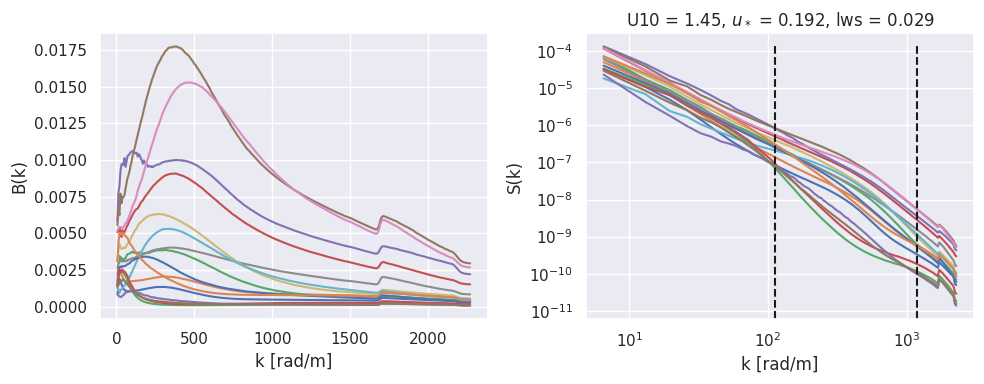

In [ ]:
content = load_mat(data_file)
print(content.keys())
content = content['omnidirectional_sat_spect']
Bs = content['B']
ks = content['k']
U10s = table1_laxague2018.U10
u_stars = table1_laxague2018.u_star
lwss = table1_laxague2018.kpHs_2
fig, ax = plt.subplots(figsize=(10, 4), ncols=2)
max_S = 0
min_S = 0
for i in range(len(Bs)):
    ks_run = ks[i][0,0]
    Bs_run = Bs[i][0,0]
    Es_run = Bs_run/(ks_run)**2
    max_S = max(max_S, max(Es_run))
    min_S = min(min_S, min(Es_run))
    ax[0].plot(ks_run, Bs_run)
    ax[0].set_xlabel(r'k [rad/m]')
    ax[0].set_ylabel(r'B(k)')
    ax[1].loglog(ks_run, Es_run)
    ax[1].set_xlabel(r'k [rad/m]')
    ax[1].set_ylabel(r'S(k)')
    ax[1].set_title(rf'U10 = {U10s[i]}, $u_*$ = {u_stars[i]}, lws = {lwss[i]}')
    plt.tight_layout()
ax[1].loglog([112.7, 112.7], [min_S, max_S], 'k--')
ax[1].loglog([1173, 1173], [min_S, max_S], 'k--')

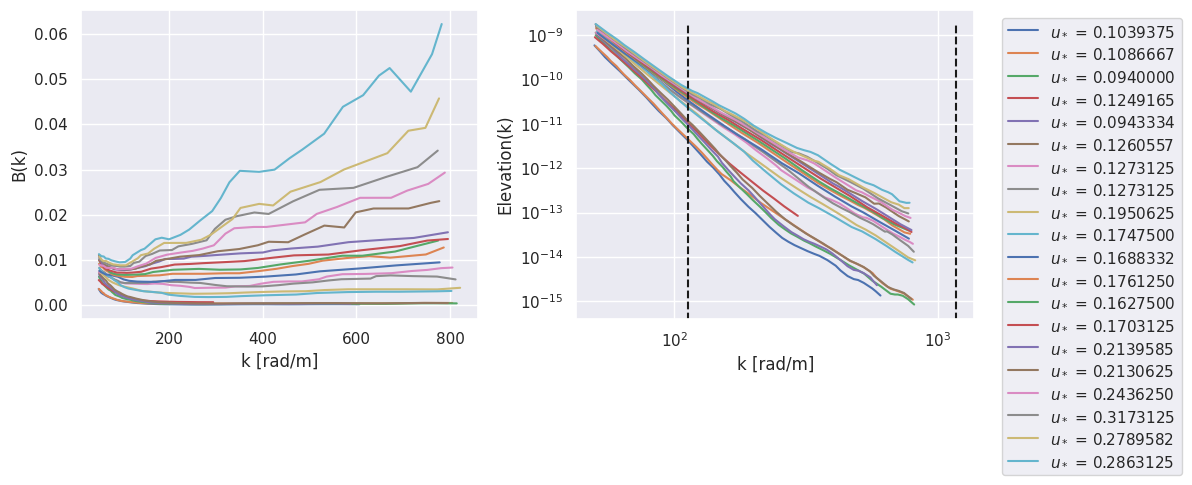

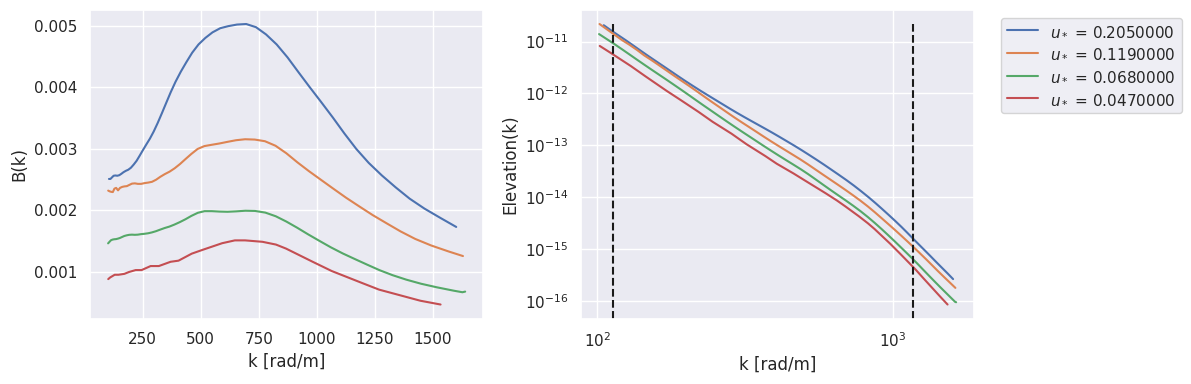

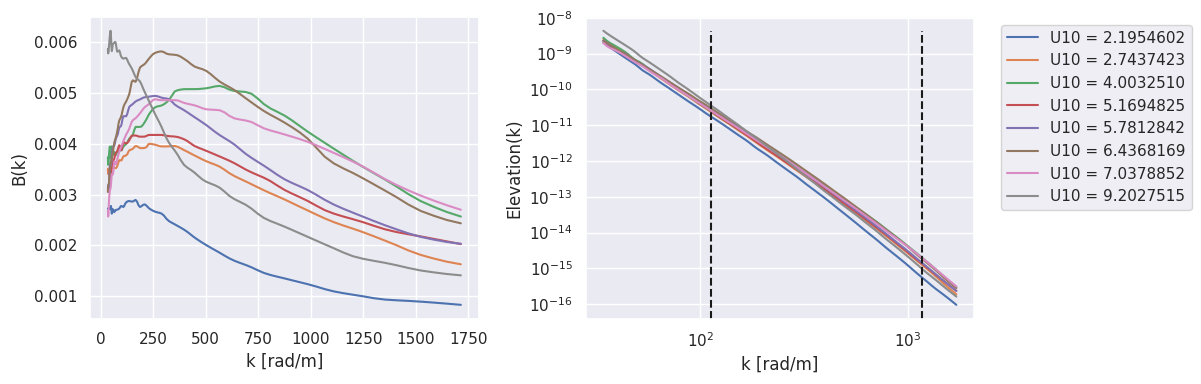

In [ ]:
comparison_datakey = ['hara_spect', 'hwang_96', 'L15_jgr_spect']

for i, name in enumerate(comparison_names):
    path = data_dir / f'{name}.mat'
    with h5py.File(path, 'r') as f:
        g = f[comparison_datakey[i]]
        assert isinstance(g, h5py.Group)
        if name == 'hwang_96':
            Bs = g['b']
        else:
            Bs = g['B']
        ks = g['k']
        if name == 'laxague_15':
            U10s = g['u10']
            u_stars = None
        else:
            U10s = None
            u_stars = g['ustar']
        fig, ax = plt.subplots(figsize=(10, 4), ncols=2)
        max_S = 0
        min_S = 0
        for i in range(len(Bs)):
            if name == 'laxague_15':
                ks_run = f[ks[i,0]][:,0]
                Bs_run = f[Bs[i,0]][:,0]
            else:
                ks_run = f[ks[i,0]][0,:]
                Bs_run = f[Bs[i,0]][0,:]
            Es_run = Bs_run/(ks_run)**4
            if U10s is not None:
                labtext = rf'U10 = {np.round(f[U10s[i,0]][0,0],7):.7f}'
            elif u_stars is not None:
                labtext = rf'$u_*$ = {np.round(f[u_stars[i,0]][0,0],7):.7f}'
            else:
                labtext = None
            max_S = max(max_S, max(Es_run))
            min_S = min(min_S, min(Es_run))
            ax[0].plot(ks_run, Bs_run)
            ax[0].set_xlabel(r'k [rad/m]')
            ax[0].set_ylabel(r'B(k)')
            ax[1].loglog(ks_run, Es_run, label=labtext)
            ax[1].set_xlabel(r'k [rad/m]')
            ax[1].set_ylabel(r'Elevation(k)')
            
        ax[1].loglog([112.7, 112.7], [min_S, max_S], 'k--')
        ax[1].loglog([1173, 1173], [min_S, max_S], 'k--')
        ax[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()    

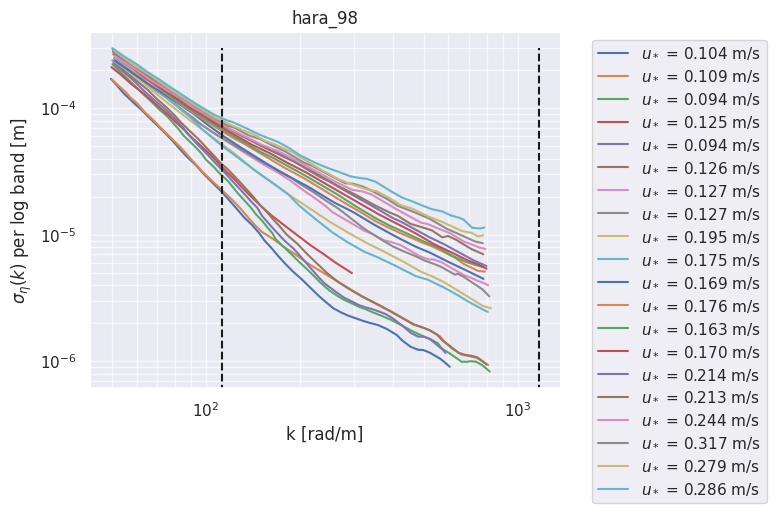

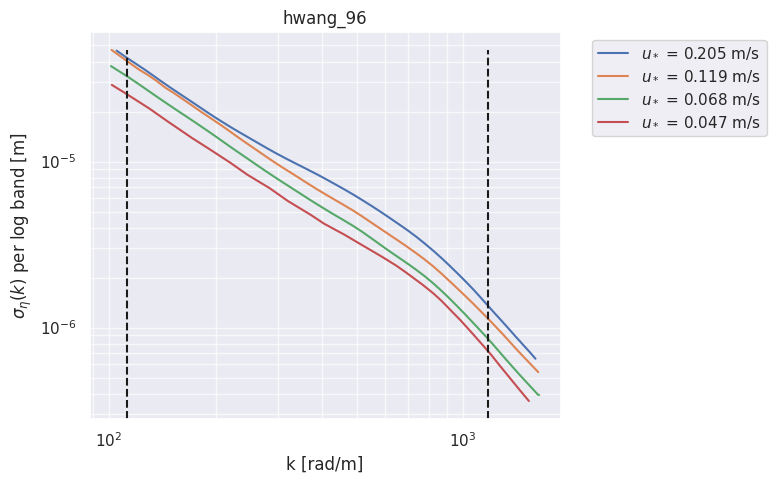

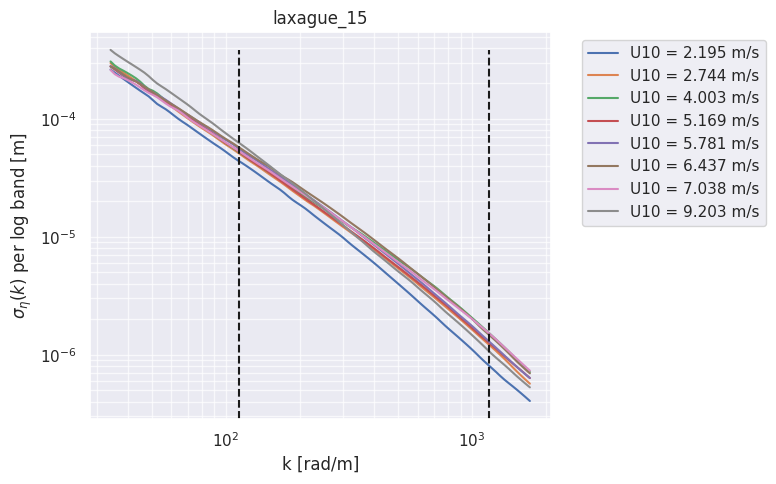

In [172]:
for i, name in enumerate(comparison_names):
    path = data_dir / f'{name}.mat'
    with h5py.File(path, 'r') as f:
        g = f[comparison_datakey[i]]
        assert isinstance(g, h5py.Group)
        if name == 'hwang_96':
            Bs = g['b']
        else:
            Bs = g['B']
        ks = g['k']
        if name == 'laxague_15':
            U10s = g['u10']
            u_stars = None
        else:
            U10s = None
            u_stars = g['ustar']
        fig, ax = plt.subplots(figsize=(8, 5))
        max_S = 0
        min_S = 0
        for i in range(len(Bs)):
            if name == 'laxague_15':
                ks_run = f[ks[i,0]][:,0]
                Bs_run = f[Bs[i,0]][:,0]
            else:
                ks_run = f[ks[i,0]][0,:]
                Bs_run = f[Bs[i,0]][0,:]
            sigma_eta = np.sqrt(Bs_run / ks_run**3)   # per log-k band, units: m
            if U10s is not None:
                labtext = rf'U10 = {np.round(f[U10s[i,0]][0,0],3):.3f} m/s'
            elif u_stars is not None:
                labtext = rf'$u_*$ = {np.round(f[u_stars[i,0]][0,0],3):.3f} m/s'
            else:
                labtext = None
            max_S = max(max_S, max(sigma_eta))
            min_S = min(min_S, min(sigma_eta))
            ax.loglog(ks_run, sigma_eta, label=labtext)
            ax.set(xlabel='k [rad/m]', ylabel=r'$\sigma_\eta(k)$ per log band [m]')
        ax.loglog([112.7, 112.7], [min_S, max_S], 'k--')
        ax.loglog([1173, 1173], [min_S, max_S], 'k--')
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        ax.grid(alpha=0.7, which='both')
        ax.set_title(name)
        plt.tight_layout()    